# Autoregressive image models

The other notebooks in this folder learn a distribution by *transporting* noise into data —
a diffusion or flow ODE. An autoregressive model does something different and much more
literal: it factorises the image exactly,

$$p(x) = \prod_{t} p(x_t \mid x_{<t}),$$

and learns each conditional with a causal transformer over the pixels read in raster order.

The trade is clean. Training is one forward pass and an exact likelihood — no ELBO, no
score matching, nothing to approximate. Sampling costs one forward pass **per pixel**,
which is why this family lost to diffusion for large images and still wins whenever you
actually need the likelihood.

MNIST is downsampled to 14×14 and binarized so the whole notebook runs on a CPU in a few
minutes. `examples/nn/images/ar_transformer.py` is the same model at full 28×28 with
256-way pixel values and multi-device training.

In [1]:
import time
from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from datasets import disable_progress_bars, load_dataset
from flax import nnx

from probjax.nn import LearnablePosEncode, Transformer
from probjax.nn.pallas_kernels import CausalMask

SIDE = 14
NUM_PIXELS = SIDE * SIDE
BOS = 2  # begin-of-sequence token, distinct from the two pixel values

disable_progress_bars()
# datasets>=5 / huggingface_hub>=1 require the namespaced repo id.
mnist = load_dataset("ylecun/mnist", keep_in_memory=True)
mnist.set_format(type="numpy", columns=["image"])

images = np.asarray(mnist["train"]["image"], dtype=np.float32) / 255.0
images = images.reshape(-1, SIDE, 2, SIDE, 2).mean(axis=(2, 4))  # 28x28 -> 14x14
data = jnp.asarray((images > 0.5).astype(np.int32).reshape(-1, NUM_PIXELS))

print("data:", data.shape, f"({float(data.mean()):.1%} of pixels are on)")

/Users/manug/src/probjax/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


data: (60000, 196) (12.7% of pixels are on)


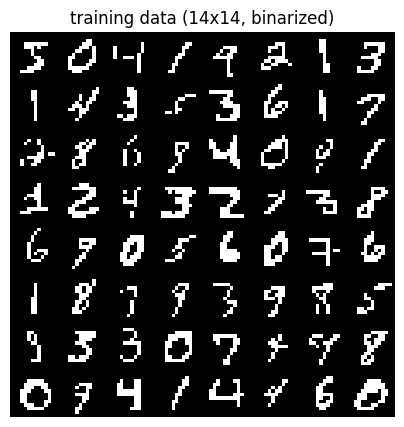

In [2]:
def show_grid(sequences, title, rows=8, cols=8):
    grid = np.asarray(sequences[: rows * cols]).reshape(rows, cols, SIDE, SIDE)
    grid = grid.transpose(0, 2, 1, 3).reshape(rows * SIDE, cols * SIDE)
    plt.figure(figsize=(5, 5))
    plt.imshow(grid, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


show_grid(data, "training data (14x14, binarized)")

## The model

Exactly the decoder from `examples/nn/nets/transformer.ipynb`, just with 196 pixel tokens
instead of 24 bits:

- pixels are **tokens**, embedded from a 3-symbol vocabulary (off, on, begin-of-sequence);
- `LearnablePosEncode` tells the model where in the raster each token sits;
- `mask=CausalMask()` stops position *t* from seeing anything after it;
- shifting the input right by one means predicting $x_t$ never gets to look at $x_t$.

Those last two together are the entire autoregressive property. Get either wrong and the
loss drops beautifully while the model learns nothing — it is copying.

In [3]:
class PixelDecoder(nnx.Module):
    def __init__(self, dim, rngs):
        self.embed = nnx.Embed(3, dim, rngs=rngs)  # {off, on, BOS}
        self.pos = LearnablePosEncode(dim, max_seq_len=NUM_PIXELS, rngs=rngs)
        self.body = Transformer(dim, num_heads=4, num_layers=2, attn_size=16, rngs=rngs)
        self.head = nnx.Linear(dim, 2, rngs=rngs)

    def __call__(self, tokens):
        hidden = self.pos(self.embed(tokens))
        return self.head(self.body(hidden, mask=CausalMask()))


def shift_right(x):
    bos = jnp.full((x.shape[0], 1), BOS, jnp.int32)
    return jnp.concatenate([bos, x[:, :-1]], axis=1)


model = PixelDecoder(64, nnx.Rngs(0))
params = sum(p.size for _, p in nnx.to_flat_state(nnx.state(model, nnx.Param)))
print(f"{params:,} parameters")

112,834 parameters


## Training

The loss is plain cross entropy, and because the factorisation is exact it *is* the
negative log likelihood. Divide by $\log 2$ to read it as **bits per pixel** — the average
number of bits this model would need to store one pixel of an MNIST digit.

The comparison that makes the number mean something: a model that ignored the image
entirely and just used the marginal on-pixel rate would spend the pixel entropy, about
0.55 bits. Anything below that is structure the transformer found.

trained in 120s
model:    0.215 bits/pixel
marginal: 0.550 bits/pixel  <- ignoring all spatial structure


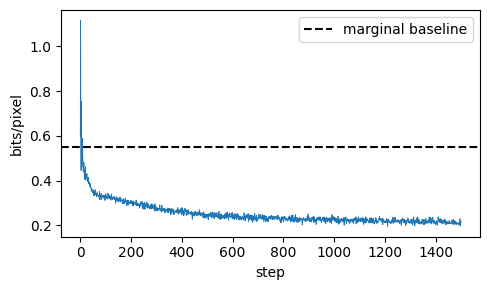

In [4]:
optimizer = nnx.Optimizer(model, optax.adamw(1e-3), wrt=nnx.Param)


@nnx.jit
def train_step(model, optimizer, batch):
    def loss_fn(m):
        logits = m(shift_right(batch))
        return optax.softmax_cross_entropy_with_integer_labels(logits, batch).mean()

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    return loss


key = jax.random.key(0)
losses = []
start = time.time()
for step in range(1500):
    key, subkey = jax.random.split(key)
    idx = jax.random.randint(subkey, (64,), 0, data.shape[0])
    losses.append(float(train_step(model, optimizer, data[idx])))

rate = float(data.mean())
baseline = -(rate * np.log2(rate) + (1 - rate) * np.log2(1 - rate))
print(f"trained in {time.time() - start:.0f}s")
print(f"model:    {np.mean(losses[-100:]) / np.log(2):.3f} bits/pixel")
print(f"marginal: {baseline:.3f} bits/pixel  <- ignoring all spatial structure")

plt.figure(figsize=(5, 3))
plt.plot(np.array(losses) / np.log(2), lw=0.6)
plt.axhline(baseline, color="k", ls="--", label="marginal baseline")
plt.xlabel("step")
plt.ylabel("bits/pixel")
plt.legend()
plt.tight_layout()

## Sampling

Raster order, one pixel at a time: run the model, sample from the logits at the current
position, write the result back, continue. `vmap` over the keys generates the whole batch
in parallel — the *sequence* is serial, the batch is not.

This is the naive $O(T)$-forward-passes decoder with no KV cache, so it re-reads the whole
prefix at every step. At 196 pixels that is cheap; at 784 it is why the training script
exists.

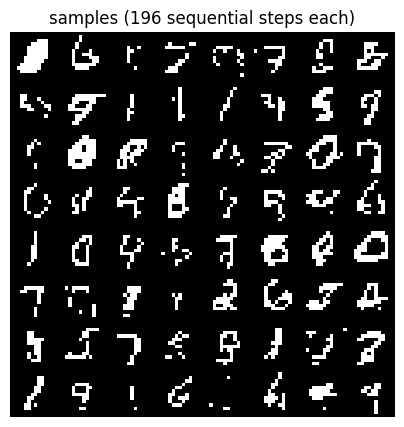

In [5]:
@partial(nnx.jit, static_argnums=(2,))
def sample(model, keys, num_pixels):
    def one_image(key):
        def body(t, carry):
            tokens, out, key = carry
            logits = model(tokens[None])[0, t]
            key, subkey = jax.random.split(key)
            pixel = jax.random.categorical(subkey, logits).astype(jnp.int32)
            tokens = jnp.where(jnp.arange(num_pixels) == t + 1, pixel, tokens)
            return tokens, out.at[t].set(pixel), key

        prompt = jnp.full((num_pixels,), BOS, jnp.int32)
        _, out, _ = jax.lax.fori_loop(
            0, num_pixels, body, (prompt, jnp.zeros((num_pixels,), jnp.int32), key)
        )
        return out

    return jax.vmap(one_image)(keys)


samples = sample(model, jax.random.split(jax.random.key(7), 64), NUM_PIXELS)
show_grid(samples, "samples (196 sequential steps each)")

Strokes, closed loops, roughly digit-shaped blobs — and plenty that are not digits. That
is a 2-layer, 64-wide model trained for 1500 steps on a laptop CPU, and the notebook is
sized for that rather than for pretty pictures. The method is not the limitation here.

### Completing a partial image

Because the factorisation is left-to-right, conditioning on a *prefix* is free — clamp the
first pixels to a real image and let the model finish the rest. No retraining, no guidance.
(Conditioning on an arbitrary *subset* is not free in this family; that is what
`simformer.ipynb` is for.)

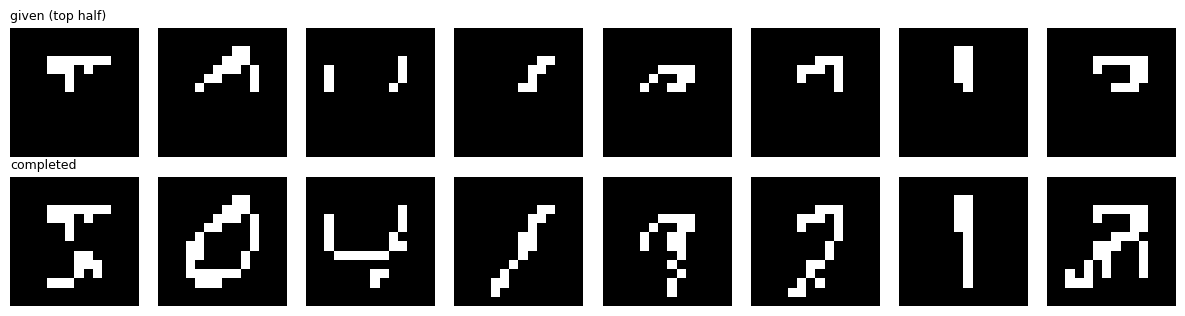

In [6]:
@partial(nnx.jit, static_argnums=(3,))
def complete(model, keys, prefixes, num_given):
    def one_image(key, prefix):
        def body(t, carry):
            tokens, out, key = carry
            logits = model(tokens[None])[0, t]
            key, subkey = jax.random.split(key)
            sampled = jax.random.categorical(subkey, logits).astype(jnp.int32)
            # Keep the given pixels, sample the rest.
            pixel = jnp.where(t < num_given, prefix[t], sampled)
            tokens = jnp.where(jnp.arange(NUM_PIXELS) == t + 1, pixel, tokens)
            return tokens, out.at[t].set(pixel), key

        prompt = jnp.full((NUM_PIXELS,), BOS, jnp.int32)
        _, out, _ = jax.lax.fori_loop(
            0, NUM_PIXELS, body, (prompt, jnp.zeros((NUM_PIXELS,), jnp.int32), key)
        )
        return out

    return jax.vmap(one_image)(keys, prefixes)


given = NUM_PIXELS // 2  # top half
originals = data[:8]
completions = complete(model, jax.random.split(jax.random.key(3), 8), originals, given)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for col in range(8):
    masked = np.asarray(originals[col]).copy()
    masked[given:] = 0
    axes[0, col].imshow(masked.reshape(SIDE, SIDE), cmap="gray")
    axes[1, col].imshow(np.asarray(completions[col]).reshape(SIDE, SIDE), cmap="gray")
    for row in range(2):
        axes[row, col].axis("off")
axes[0, 0].set_title("given (top half)", loc="left", fontsize=9)
axes[1, 0].set_title("completed", loc="left", fontsize=9)
fig.tight_layout()

## Scaling up: `examples/nn/images/ar_transformer.py`

The same model at production settings, as a script rather than a notebook:

- full 28×28 resolution — 784 tokens instead of 196;
- **256-way categorical** pixel values instead of binary. Only two lines change,
  `nnx.Embed(257, dim)` and `nnx.Linear(dim, 256)`, plus `BOS = 256`; bits/dim is then
  reported over 256 levels and is directly comparable to the numbers in the literature;
- `flex_attention` with `CausalMask()` for the fused kernel (see
  `examples/nn/nets/attention.ipynb`);
- data augmentation, warmup + cosine decay, checkpointing, multi-device training.

```bash
python examples/nn/images/ar_transformer.py --num-steps 50000 --batch-size 128
```

## Where to go next

- `examples/nn/nets/transformer.ipynb` — the causal decoder in miniature.
- `simformer.ipynb` — conditioning on arbitrary subsets rather than prefixes.
- `diffusion.ipynb`, `flow_matching.ipynb` — the transport-based alternatives, which
  sample in tens of steps instead of one per dimension, but give up the exact likelihood.